# Supplementary File 3: Nuclei Area Quantification
for ``Four-Fold Expansion Microscopy of Cultured Cells"
by Corban Swain, Sapna Sinha, and Ed Boyden

*Jupyter Notebook (converted to `.pdf`) containing ImageJ commands and Python script for quantification of nuclei area 
from images.*

## 1. Setting Up Repository and Opening the Notebook
1. You will need to install and set up the following software before continuing:
   - [ ] [**git** https://git-scm.com/](https://git-scm.com/)
   - [ ] [**mamba** https://mamba.readthedocs.io](https://mamba.readthedocs.io/en/latest/installation/mamba-installation.html)
   - [ ] [**Fiji (ImageJ)** https://imagej.net/software/fiji/downloads](https://imagej.net/software/fiji/downloads)
         (version 1.54p was used)
2. Clone the
   [**ExM-Demo-Figures** repository (https://github.com/CorbanSwain/ExM-Demo-Figures)](https://github.com/CorbanSwain/ExM-Demo-Figures)
   into a directory (e.g. `~/ExM-Demo-Figures`) on your computer. Then initialize and update the submodules.
   ```
   cd ~
   git clone https://github.com/CorbanSwain/ExM-Demo-Figures ~/ExM-Demo-Figures
   git submodule update --init
   ```
4. Set up the Python environment according to the environment configuration provided in the repository.
   ```
   cd ~/ExM-Demo-Figures/envs/
   mamba create -f exm-demo-fig-py3.12-env.yml
   ```
5. Then run JupyterLab and open this notebook via the JupyterLab interface.
   ```
   cd ~/ExM-Demo-Figures/source
   mamba activate exm-demo-fig-py3.12-env 
   jupyter lab supplementary_file_03-nuc-area.ipynb
   ```

## 2. Segmentation and Measurement of Images in Fiji
Follow these instructions to process the images for nuclei area quantification.

1. **Open Image**
   - Run Fiji and open the image located at `~/ExM-Demo-Figures/data/nuc-size-analysis/expanded-hex-cells-a.tif` *This
     is fluorescent microscope image of expanded HEK cells taken with a 40x objective on a Nikon CSU-W1. The DAPI
     channel has already been separated as its own image file.*
   - This image has embedded scale information (i.e. 5.8954 px/micron). If an image being analyzed does not have scale
     information, it should first be set via the `Analyze > Set Scale...` dialog.
   - `Image > Adjust > Brightness/Contrast...` 
     - Click `Reset`
     - Click `Auto`
   - `LUT` Toolbar Button > `Grays`
3. **Duplicate Image**
   - `Image > Duplicate...`
   - `Title:` = `expanded-hek-cells-a-MASK.tif`
   - Perform the following steps on the `expanded-hek-cells-a-MASK.tif` file.
4. **Histogram Normalization**
   - `Process > Enhance Local Contrast (CLAHE)`
   - `blocksize:` = `255` for expanded samples (`63` for unexpanded)
   - `histogram bins:` = `256`
   - `maximum slope:` = `2.00`
   - `mask:` = `*None*`
   - `fast` = NO
6. **Thresholding**
   - `Image > Adjust > Threshold...`
   - lower threshold value: Adjust until approximately 25% of pixels are selected. *This target percentage may need to
     be adjusted based on cell confluency.*

     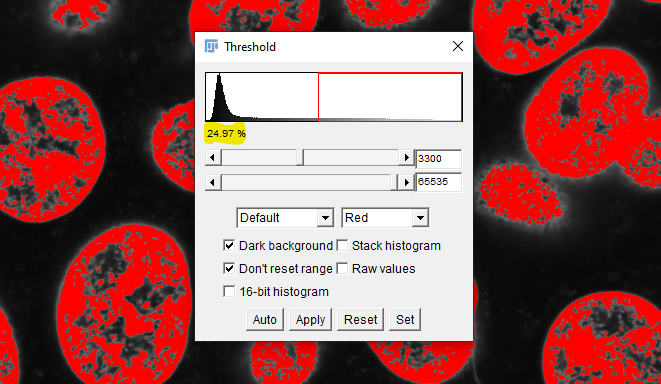

   - upper threshold value: maximum
   - method: `Default`
   - color: `Red`
   - `Dark background` = YES
   - `Don't reset range` = YES
   - `16-bit histogram` = NO
   - `Stack histogram` = NO
   - `Raw values` = NO
   - Finally, click `Apply`.
8. **Binary Closing**
   - `Process > Binary > Options...`
   - `Iterations:` = `4` for expanded samples (`1` for unexpanded)
   - `Count:` = `1`
   - `Black background` =  YES
   - `Pad edges when eroding` = YES
   - `EDM output:` = `8-bit`
   - `Do:` = `Close`
9. **Binary Fill Holes**
    - `Process > Binary > Fill Holes`
10. **Watershed Segmentation**
    - `Process > Binary Watershed`
12. **Save Mask**
    - `File > Save...`
    - Save in: `~/ExM-Demo-Figures/data/nuc-size-analysis/`
    - File name: `expanded-hek-cells-a-MASK.tif`
13. **Analyze**
    - `Analyze > Analyze Set Measurements...`
       - `Area` = YES
       - *all others* = NO
       - `Decimal Places:` = `3`
    - `Analyze > Analyze Particles...`
       - `Size (micron^2):` = `500-4000` for expanded samples (`31-250` for unexpanded)
       - `Pixel units` = NO
       - `Circularity:` = `0.5-1.00`
       - `Show:` = `Overlay`
       - `Display results` = YES
       - `Clear results` = YES
       - `Summarize` = NO
       - `Add to Manager` = NO
       - `Record starts` = NO
       - `Exclude on edges` = YES
       - `Include holes` = YES
       - `Overlay` = YES
       - `Composite ROIs` = NO
12. **Save Results**
    - Select the window `Results`
    - `File > Save As` (Within the Results window, not the Fiji toolbar)
    - Save in: `~/ExM-Demo-Figures/data/nuc-size-analysis/`
    - File name: `expanded-hek-cells-a-RESULTS.csv`    
12. **Transfer Regions**
    - Select the window `expanded-hek-cells-a-MASK.tif`
    - `Image > Overlay > To ROI Manager` *the ROI Manager window should now be open.*
    - Select the window `expanded-hek-cells-a.tif`
    - Select the window `ROI Manager`
    - Click the first region (i.e. `1-1`) in the ROI manager region list.
    - Click `Update`. *All of the regions should now be overlaid on the original image.*
12. **Inspect Regions**
    - Use the ROI Manager to view each region in the original image by selecting each region label from the ROI
      Manager's list or by clicking the region in the image. If a region does not appear to be a complete,
      non-dividing nucleus, select it and click `Delete`, then continue to the next region.
    - Once all the regions have been reviewed in this way, transfer the indices of the remaining good regions into the
      Python list below (section 3.3.3), setting the variable named
      `good_roi_exm_a_list`. The expected result for `expanded-hek-cells-a` is
      ```python
      good_roi_exm_a_list = range(2, 28)  # regions 2 - 27 are good; region 1 is a partial nucleus
      ```
13. **Annotate Original Image**
    - In the ROI Manager, click `Deselect`
    - Click `Properties...`
      - `Range:` = *should automatically be filled in with the range of all the regions (e.g 1-26)*
      - `Position:` = `none`
      - `Group:` = `none`
      - `Stroke color:` = `yellow`
      - `Width:` = `4`
      - `Fill color:` = `none`
      - `List coordinates` = NO
    - In the main Fiji toolbar, select `Image > Overlay > Labels...`
      - `Color:` = `yellow`
      - `Font size` = `24` *adjust as needed*
      - `Show labels` = YES
      - `Use names as labels` = NO
      - `Draw backgrounds` = NO
      - `Bold` = NO
    - In the ROI Manager, click `Deselect`
    - In the ROI Manager, click `Flatten [F]` *this should open a new image window*
    - In the main Fiji toolbar, select `File > Save As > PNG...` to save the new image
      - Save in: `~/ExM-Demo-Figures/data/nuc-size-analysis/`
      - File name: `expanded-hek-cells-a-ANNOTATED.png`

Repeat this process for each of the other nuclei images to be analyzed: `expanded-hek-cells-b.tif` and 
`normal-hek-cells.tif`.

## 3. Analysis, Plotting of Nuclei Sizes with Python
Run the following cells to process the extracted results data.

### 3.1 Package Imports

In [1]:
# 3.1.1 base and metaprogramming imports
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

# 3.1.2 ipynb-specific imports
try:
    import ipynbname
except Exception as e:
    warnings.warn(f'`ipynbname` module import failed with error: {e!r}')
    ipynbname = None
    
if ipynbname is not None:
    _file = ipynbname.path()
else:
    # manually set the full path to the current notebook below if `ipynbname` 
    # import fails
    _file = ''

# 3.1.3 key path variables and management
source_dir = os.path.split(_file)[0]
repo_dir = os.path.abspath(os.path.join(source_dir, '..'))
data_dir = os.path.join(repo_dir, 'data')
figure_dir = os.path.join(repo_dir, 'figures')
if source_dir not in sys.path:
    sys.path.append(source_dir)

print('Imports done.')

Imports done.


### 3.2 Plotting Defaults

In [2]:
# 3.2.1 load custom fonts, if available
custom_fonts = [
    'C:\\Windows\\Fonts\\Linotype - HelveticaLTPro-Black.otf',
    'C:\\Windows\\Fonts\\Linotype - HelveticaLTPro-Bold.otf',
    'C:\\Windows\\Fonts\\Linotype - HelveticaLTPro-Roman.otf',
    'C:\\Windows\\Fonts\\Linotype - HelveticaLTPro-Oblique.otf']
for font_path in custom_fonts:
    if os.path.exists(font_path):
        print(f'Adding font: "{os.path.split(font_path)[-1]}" to mpl.')
        mpl.font_manager.fontManager.addfont(font_path)

# 3.2.2 set plotting style
sns.set_style(
    'ticks',
    {'font.sans-serif': [
        'Helvetica LT Pro', 'Helvetica', 'Arial', 'sans-serif'],
     'mathtext.fontset': ['cm',],
     'axes.linewidth': 2})

# 3.2.3 set axis and figure defaults
axes_lw = 1.25
mpl.rcParams['axes.linewidth'] = axes_lw
mpl.rcParams['xtick.major.width'] = axes_lw
mpl.rcParams['xtick.minor.width'] = axes_lw
mpl.rcParams['ytick.major.width'] = axes_lw
mpl.rcParams['ytick.minor.width'] = axes_lw

mpl.rcParams['axes.facecolor'] = 'none'

mpl.rcParams['figure.frameon'] = False
mpl.rcParams['figure.facecolor'] = 'none'
mpl.rcParams['figure.edgecolor'] = 'none'

print('Plotting defaults set; done.')

Adding font: "Linotype - HelveticaLTPro-Black.otf" to mpl.
Adding font: "Linotype - HelveticaLTPro-Bold.otf" to mpl.
Adding font: "Linotype - HelveticaLTPro-Roman.otf" to mpl.
Adding font: "Linotype - HelveticaLTPro-Oblique.otf" to mpl.
Plotting defaults set; done.


### 3.3 Filepaths and Other Parameter Inputs

In [3]:
# 3.3.1 filepath names
# Edit these fields to match the files you wish to analyze.
nuc_size_dname = 'nuc-size-analysis'
normal_fname = 'normal-hek-cells-RESULTS.csv'
exm_a_fname = 'expanded-hek-cells-a-RESULTS.csv'
exm_b_fname = 'expanded-hek-cells-b-RESULTS.csv'

figure_name = 'nuc_size_comparison'  # output figure name

# 3.3.2 table keys
blank_index_key = ' '  # Fiji populates the results `.csv` with a blank 
                       # header for the first/index column
index_key = 'original_index'
category_key = 'category'
expanded_cat_name = 'expanded'
unexpanded_cat_name = 'normal'
file_key = 'original_file'
area_key = 'Area'
sqrt_area_key = '[Area]^(1/2)'

# 3.3.3 good region list (from manual inspection)
good_roi_normal_list = [
    9,   13,  15,  17,  19,  20,  21,  26,  28,  29,  
    30,  31,  35,  36,  37,  38,  39,  40,  41,  43,  
    44,  45,  46,  47,  48,  49,  51,  54,  55,  57,  
    58,  59,  60,  61,  63,  65,  68,  69,  70,  75,  
    76,  78,  79,  81,  82,  83,  84,  85,  86,  87,  
    90,  92,  94,  96,  99,  103, 104, 105, 106, 109, 
    111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 
    124, 128, 134, 137, 138, 142, 143, 144, 145, 148, 
    150, 152, 153, 154, 155, 156, 163, 164, 166, 170, 
    173, 174, 176, 177, 178, 180, 181, 184, 186, 188, 
    189, 190, 191, 192, 193, 194, 198, 199, 200, 201, 
    202, 204, 207, 209, 212, 213, 214, 215, 219, 220, 
    221, 222, 224, 225, 228, 231, 234, 235, 236, 237, 
    241, 242, 243, 246, 247, 249, 252, 254, 260, 264, 
    265, 267, 268, 270, 280, 281, 287, 288]
good_roi_exm_a_list = range(2, 28)  # 2 to 27, inclusive
good_roi_exm_b_list = range(1, 29)  # all regions, 1 to 28, inclusive

print('Parameters set; done.')

Parameters set; done.


### 3.4 Loading and Processing Data Tables

In [4]:
# 3.4.1 generate full paths to files
nuc_size_dir = os.path.join(data_dir, nuc_size_dname)
normal_path = os.path.join(nuc_size_dir, normal_fname)
exm_a_path = os.path.join(nuc_size_dir, exm_a_fname)
exm_b_path = os.path.join(nuc_size_dir, exm_b_fname)

# 3.4.2 load `.csv` files into pandas `DataFrame`s
raw_normal_df = pd.read_csv(normal_path)
raw_exm_a_df = pd.read_csv(exm_a_path)
raw_exm_b_df = pd.read_csv(exm_b_path)

# 3.4.3 process the raw tables
def process_raw_df(raw_df, fname, cat_name, good_roi_list):
    df = raw_df.copy()
    df[file_key] = fname
    df[category_key] = cat_name
    df = df.rename(columns={blank_index_key: index_key})
    df = df[df[index_key].isin(list(good_roi_list))]
    return df.reset_index(drop=True)

normal_df = process_raw_df(
    raw_normal_df, normal_fname, unexpanded_cat_name, good_roi_normal_list)
exm_a_df = process_raw_df(
    raw_exm_a_df, exm_a_fname, expanded_cat_name, good_roi_exm_a_list)
exm_b_df = process_raw_df(
    raw_exm_b_df, exm_b_fname, expanded_cat_name, good_roi_exm_b_list)

# 3.4.4 make a concatenated table of all data points
nuc_size_df = (
    pd.concat([exm_a_df, exm_b_df, normal_df])
    .reset_index(drop=True))
nuc_size_df[category_key] = nuc_size_df[category_key].astype('category')
nuc_size_df[sqrt_area_key] = np.sqrt(nuc_size_df[area_key])

# 3.4.5 log table information and preview
def print_df_info(df, name):
    print(f'\n{"v"*25} {name} Data Frame: {"v"*25}')
    df.info(memory_usage=False)
    print()
    print(df.head(2))

def print_df_infos(raw_df, df, name):    
    print_df_info(raw_df, 'Raw ' + name)
    print_df_info(df, name)

print_df_infos(raw_normal_df, normal_df, 'NORMAL')
print_df_infos(raw_exm_a_df, exm_a_df, 'EXPANDED-A')
print_df_infos(raw_exm_b_df, exm_b_df, 'EXPANDED-B')
print_df_info(nuc_size_df, 'ALL')

print('\nData tables loaded and processed; done.')


vvvvvvvvvvvvvvvvvvvvvvvvv Raw NORMAL Data Frame: vvvvvvvvvvvvvvvvvvvvvvvvv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0           297 non-null    int64  
 1   Area    297 non-null    float64
dtypes: float64(1), int64(1)
        Area
0  1  51.732
1  2  68.362

vvvvvvvvvvvvvvvvvvvvvvvvv NORMAL Data Frame: vvvvvvvvvvvvvvvvvvvvvvvvv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   original_index  148 non-null    int64  
 1   Area            148 non-null    float64
 2   original_file   148 non-null    object 
 3   category        148 non-null    object 
dtypes: float64(1), int64(1), object(2)
   original_index    Area                 original_file category
0               9  68.995  normal-hek-cells-RESULTS.c

### 3.5 Show ROI Delete List
This is a tool to print the regions that were removed from the original ROI Manager at step 2.12 above.

In [5]:
# 3.5.1 helper function for printing a list as columns
def print_list_in_columns(data, num_columns=10, column_padding=2):
    # function partially generated by Gemeni AI, prompted by Corban Swain
    max_len = max(len(str(item)) for item in data) if data else 0
    col_width = max_len + column_padding
    for i, item in enumerate(data):
        print(str(item).ljust(col_width), end="")
        if (i + 1) % num_columns == 0:
            print()
    if len(data) % num_columns != 0:
        print()  # Print a final newline if the list doesn't perfectly fill the 
                 # last row

# 3.5.2 helper function for computing and printing the deleted regions
def print_delete_list(good_list, raw_df, name):
    good_len = len(good_list)
    total_len = len(raw_df)
    bad_len = total_len - good_len
    print(f'\nLabels of deleted ROIs for {name} dataset:')
    print(f'({good_len:d} regions kept;'
          f' {bad_len:d} regions deleted)')
    if bad_len == 0:
        print('none')
        return        
    print_list_in_columns(
        [(i+1) for i in range(total_len) if (i+1) not in good_list])

# 3.5.2 printing the delete list for each sample
print_delete_list(good_roi_normal_list, raw_normal_df, 'NORMAL')
print_delete_list(good_roi_exm_a_list, raw_exm_a_df, 'EXPANDED-A')
print_delete_list(good_roi_exm_b_list, raw_exm_b_df, 'EXPANDED-B')

print('\nDelete lists printed; done.')


Labels of deleted ROIs for NORMAL dataset:
(148 regions kept; 149 regions deleted)
1    2    3    4    5    6    7    8    10   11   
12   14   16   18   22   23   24   25   27   32   
33   34   42   50   52   53   56   62   64   66   
67   71   72   73   74   77   80   88   89   91   
93   95   97   98   100  101  102  107  108  110  
121  122  123  125  126  127  129  130  131  132  
133  135  136  139  140  141  146  147  149  151  
157  158  159  160  161  162  165  167  168  169  
171  172  175  179  182  183  185  187  195  196  
197  203  205  206  208  210  211  216  217  218  
223  226  227  229  230  232  233  238  239  240  
244  245  248  250  251  253  255  256  257  258  
259  261  262  263  266  269  271  272  273  274  
275  276  277  278  279  282  283  284  285  286  
289  290  291  292  293  294  295  296  297  

Labels of deleted ROIs for EXPANDED-A dataset:
(26 regions kept; 1 regions deleted)
1  

Labels of deleted ROIs for EXPANDED-B dataset:
(28 regions kept; 0

### 3.6 Compute Median Nuclei Sizes and *n*

In [6]:
# 3.6.1 create a pivot table computing the median sqrt area for each category
pivot = nuc_size_df.pivot_table(
    columns=category_key,
    values=sqrt_area_key,
    aggfunc='median',
    observed=True)

# 3.6.2 create pivot table counting the number of nuclei for each category
exm_median = pivot[expanded_cat_name].item()
unexm_median = pivot[unexpanded_cat_name].item()
ex_factor = exm_median / unexm_median

count_pivot = nuc_size_df.pivot_table(
    columns=category_key,
    values=sqrt_area_key,
    aggfunc='count',
    observed=True)
count_pivot = count_pivot.rename(index={sqrt_area_key: 'n'})

exm_n = count_pivot[expanded_cat_name].item()
unexm_n = count_pivot[unexpanded_cat_name].item()

print('Median [Area]^(1/2):')
print(pivot)
print()
print('Num Data Points:')
print(count_pivot)
print()
print(f'Expansion Factor: {ex_factor:.1f}x')
print('\nData summaries generated; done.')

Median [Area]^(1/2):
category      expanded    normal
[Area]^(1/2)  34.59245  8.826096

Num Data Points:
category  expanded  normal
n               54     148

Expansion Factor: 3.9x

Data summaries generated; done.


### 3.7 Create and Save Figure

Figure generated and saved; done.


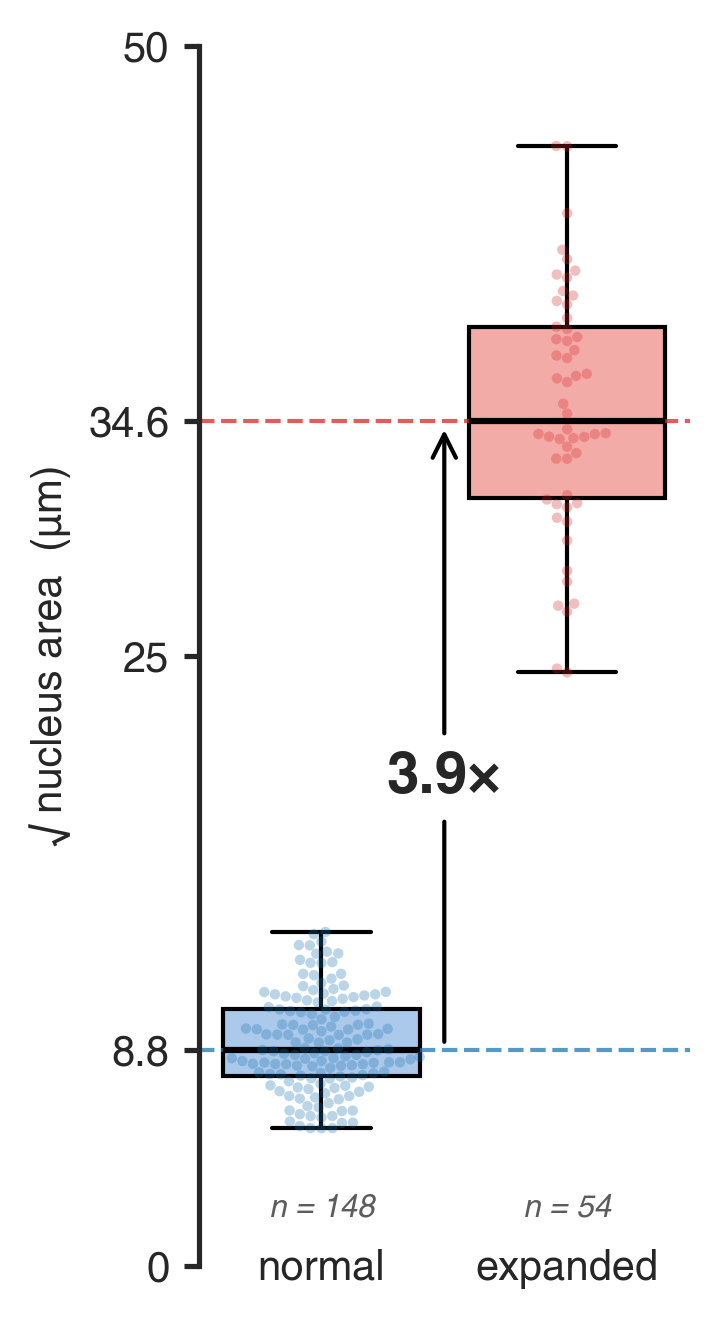

In [7]:
# 3.7.1 generate main figure object
fig = plt.figure(
    figsize=(2.5, 4.5),
    dpi=300)

# 3.7.2 set color palettes
palette_p = sns.color_palette(
    [sns.color_palette('pastel')[0],
     sns.color_palette('pastel')[3]])
palette_n = sns.color_palette(
    [sns.color_palette()[0],
     sns.color_palette()[3]])

# 3.7.3 use seaborn to plot boxplots with overlaid swarmplots from data
ax = sns.boxplot(
    data=nuc_size_df,
    x=category_key,
    y=sqrt_area_key,
    hue=category_key,
    palette=palette_p,
    order=[unexpanded_cat_name, expanded_cat_name],
    hue_order=[unexpanded_cat_name, expanded_cat_name],
    linecolor='k',
    medianprops={'lw': 1.5})
sns.swarmplot(
    data=nuc_size_df,
    x=category_key,
    y=sqrt_area_key,
    hue=category_key,
    size=2.5,
    alpha=0.3,
    ax=ax,
    palette=palette_n,
    color='k',
    order=[unexpanded_cat_name, expanded_cat_name],
    hue_order=[unexpanded_cat_name, expanded_cat_name])

# 3.7.4 plot horizontal lines at the category medians
ax.axhline(
    y=unexm_median,
    color=palette_n[0],
    ls='--',
    lw=1,
    alpha=0.75
)
ax.axhline(
    y=exm_median,
    color=palette_n[1],
    ls='--',
    lw=1,
    alpha=0.75
)

# 3.7.5 format look of axes
sns.despine(right=True, bottom=True, top=True)
ax.set_ylim(0, 50)
ax.spines['bottom'].set_bounds(0, 1)
ax.set_yticks(
    [0, 
     unexm_median,
     25,
     exm_median,
     50])
ax.set_yticklabels(
    ['0',
     f'{unexm_median:.1f}',
     '25',
     f'{exm_median:.1f}',
    '50'])
ax.set_ylabel('\u221A nucleus area  (\u00b5m)')
ax.set_xlabel(None)
ax.tick_params(axis='x', length=0, pad=-4)

# 3.7.6 annotate expansion factor
ax.annotate(
    f'{ex_factor:.1f}\u00D7',
    xy=(0.5, exm_median),
    xytext=(0.5, 20.0),
    arrowprops=dict(
        arrowstyle='->',
        color='black',
    ),
    annotation_clip=False,
    ha='center',
    va='center',
    size=14,
    weight='bold',
)
ax.annotate(
    f'{ex_factor:.1f}\u00D7',
    xy=(0.5, unexm_median),
    xytext=(0.5, 20.0),
    arrowprops=dict(
        arrowstyle='-',
        color='black',
    ),
    annotation_clip=False,
    ha='center',
    va='center',
    alpha=0,
    size=14,
    weight='bold',
)

# 3.7.8 annotate num data points
ax.text(
    0, 2, 
    f'n = {unexm_n}',
    ha='center',
    va='baseline',
    size=7.5,
    style='oblique',
    alpha=0.75)
ax.text(
    1, 2, 
    f'n = {exm_n}',
    ha='center',
    va='baseline',
    size=7.5,
    style='oblique',
    alpha=0.75)

# 3.7.9 helper function for saving figure to pdf
def save_figures(
    filename=None, 
    figs=None, 
    dpi=200, 
    fmt='pdf', 
    directory=None,
    add_filename_timestamp=True, 
    stamp_kwargs=None):
    from matplotlib.backends.backend_pdf import PdfPages

    if filename is None:
        filename = 'all_figures'

    if add_filename_timestamp:
        filename = filename + '_' + time.strftime('%y%m%d-%H%M')

    if figs is None:
        figs = [plt.figure(n) for n in plt.get_fignums()]
    else:
        try:
            _ = iter(figs)
        except TypeError:
            figs = [figs, ]

    if stamp_kwargs:
        [stamp_fig(fig, **stamp_kwargs) for fig in figs]

    directory = 'figures' if directory is None else directory
    try:
        os.mkdir(directory)
    except FileExistsError:
        pass

    file_path = os.path.join(directory, filename)
    if fmt == 'pdf':
        file_path += '.pdf'
        with PdfPages(file_path) as pp:
            for fig in figs:
                fig.savefig(pp, format='pdf', dpi=dpi)
    else:
        for i, fig in enumerate(figs):
            fig.savefig('%s_%d.%s' % (file_path, i, fmt), format=fmt, dpi=dpi)

# 3.7.10 perform final layout of plot
plt.tight_layout()

# 3.7.11 export figure to pdf
save_figures(
    filename=figure_name,
    add_filename_timestamp=False,
    directory=figure_dir)

print('Figure generated and saved; done.')

## 4 Notebook Conversion 
This notebook can be converted to a `.pdf` via the following [**pandoc** (https://pandoc.org/)](https://pandoc.org/) 
command:

*for Unix-style command line:*
```bash
pandoc -o "supplementary_file_03-nuc-area.pdf" \  
    --pdf-engine=xelatex --highlight-style tango \
    -V geometry:landscape \
    -V geometry:top=0.75in,bottom=0.75in,left=1in,right=2in
    supplementary_file_03-nuc-area.ipynb
```

*for Windows Command Prompt:*
```
pandoc -o "supplementary_file_03-nuc-area.pdf" ^
    --pdf-engine=xelatex --highlight-style tango ^
    -V geometry:landscape ^
    -V geometry:top=0.75in,bottom=0.75in,left=1in,right=2in ^
    supplementary_file_03-nuc-area.ipynb
    
```